In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc ,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [238]:
df = pd.read_csv("pbl_dataset.csv")
df.head()

,Sno.,Age,Gender,Income,Employment,LoanAmount,LoanTerm,InterestRate,CreditScore,DTI,PastDefaults,NumLoans,Savings,EMI,Default
0,1,26,Male,320000,Salaried,100000,24,10.2,720.0,0.25,0,1,50000.0,4500.0,0
1,2,42,Female,780000,Self-employed,280000,36,12.1,670.0,0.37,1,2,140000.0,9800.0,0
2,3,35,Male,520000,Salaried,200000,48,11.0,600.0,0.46,2,3,80000.0,6200.0,1
3,4,30,Female,460000,Salaried,150000,36,10.0,NaN,0.30,0,1,60000.0,4800.0,0
4,5,51,Male,920000,Business,400000,60,13.5,560.0,0.55,3,4,200000.0,12500.0,1


In [239]:
df['Employment']=df['Employment'].str.replace('-','')
df['Employment']=df['Employment'].str.strip()

In [240]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Employment']=le.fit_transform(df['Employment'])

In [241]:
num_cols = ['Age','Income','LoanAmount','LoanTerm','InterestRate',
            'CreditScore','DTI','PastDefaults','NumLoans','Savings','EMI']

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [242]:
X = df.drop('Default' , axis=1)
y =df['Default']

In [243]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [244]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [245]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [246]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [247]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [248]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance:")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [249]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 Logistic Regression Performance:
Accuracy: 0.9
Precision: 1.0
Recall: 0.75
F1 Score: 0.8571428571428571

Confusion Matrix:
[[12  0]
 [ 2  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.75      0.86         8

    accuracy                           0.90        20
   macro avg       0.93      0.88      0.89        20
weighted avg       0.91      0.90      0.90        20



In [250]:
evaluate_model(y_test, y_pred_knn, "KNN")


🔹 KNN Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.875
F1 Score: 0.9333333333333333

Confusion Matrix:
[[12  0]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



In [251]:
evaluate_model(y_test, y_pred_svm, "SVM")


🔹 SVM Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.875
F1 Score: 0.9333333333333333

Confusion Matrix:
[[12  0]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



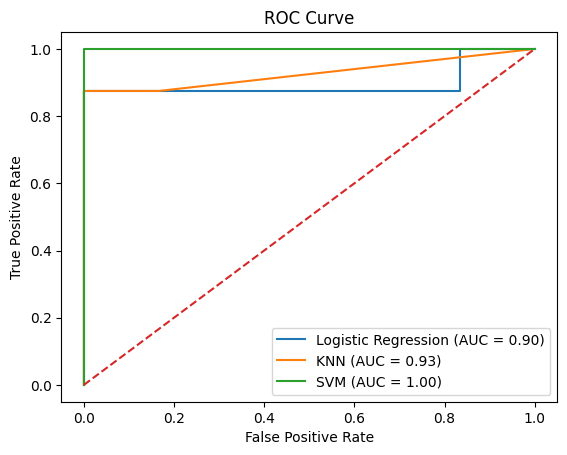

In [252]:
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, y_test, "Logistic Regression")
plot_roc(knn, X_test, y_test, "KNN")
plot_roc(svm, X_test, y_test, "SVM")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [253]:
def plot_confusion(model,X_test,y_test,title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("CONFUSION MATRIX")
    plt.show()

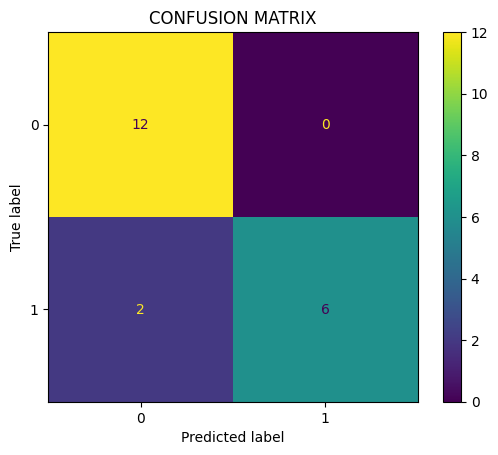

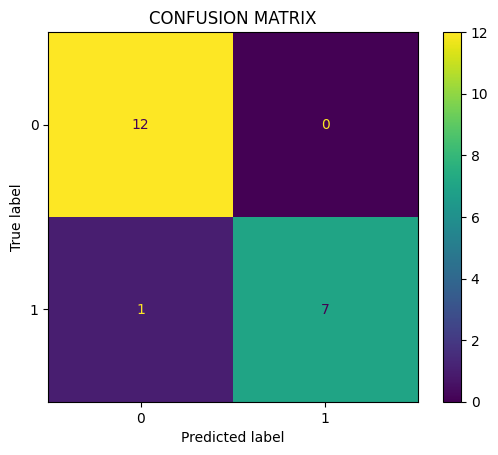

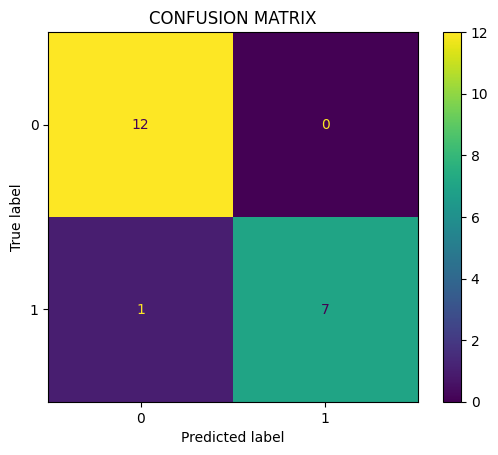

In [254]:
plot_confusion(lr, X_test, y_test, "Logistic Regression")
plot_confusion(knn, X_test, y_test, "KNN")
plot_confusion(svm, X_test, y_test, "SVM")

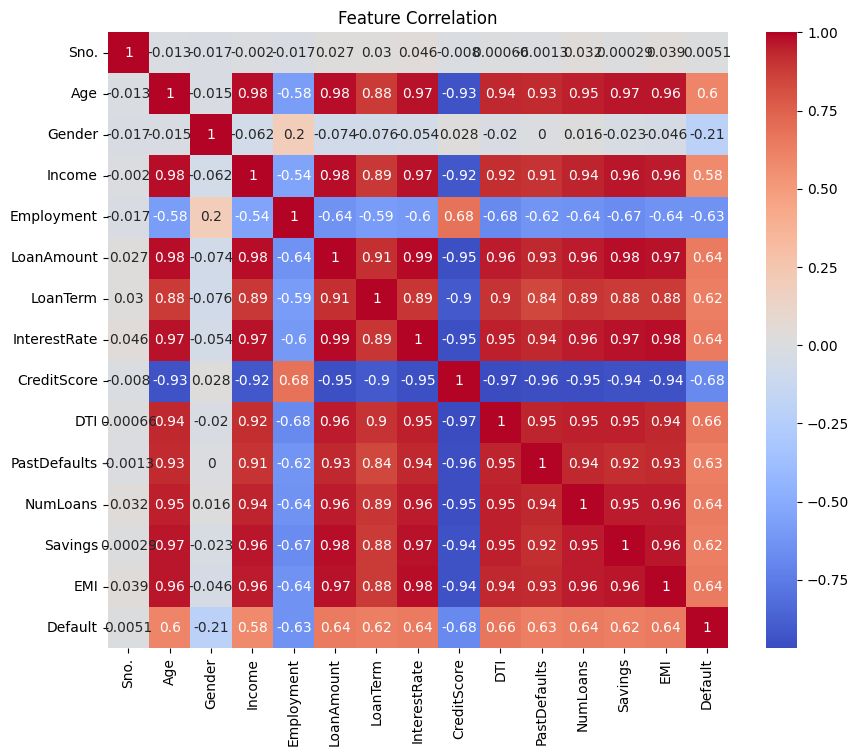

In [255]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Testing is done, predicted for loan default prediction system, model achieved overall accuracy of 93.33%, confusion matrix and classification reports are also included